In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [6]:
df=pd.read_csv('C:/Users/X/Desktop/penguins.csv')
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0,FEMALE
341,50.4,15.7,222.0,5750.0,MALE
342,45.2,14.8,212.0,5200.0,FEMALE


In [7]:
indices_to_remove=[]
for index,row in df.iterrows():
    print(index)
    print(row)

0
culmen_length_mm       39.1
culmen_depth_mm        18.7
flipper_length_mm     181.0
body_mass_g          3750.0
sex                    MALE
Name: 0, dtype: object
1
culmen_length_mm       39.5
culmen_depth_mm        17.4
flipper_length_mm     186.0
body_mass_g          3800.0
sex                  FEMALE
Name: 1, dtype: object
2
culmen_length_mm       40.3
culmen_depth_mm        18.0
flipper_length_mm     195.0
body_mass_g          3250.0
sex                  FEMALE
Name: 2, dtype: object
3
culmen_length_mm     NaN
culmen_depth_mm      NaN
flipper_length_mm    NaN
body_mass_g          NaN
sex                  NaN
Name: 3, dtype: object
4
culmen_length_mm       36.7
culmen_depth_mm        19.3
flipper_length_mm     193.0
body_mass_g          3450.0
sex                  FEMALE
Name: 4, dtype: object
5
culmen_length_mm       39.3
culmen_depth_mm        20.6
flipper_length_mm     190.0
body_mass_g          3650.0
sex                    MALE
Name: 5, dtype: object
6
culmen_length_mm       

In [8]:
indices_to_remove=[]
for index,row in df.iterrows():
    if row.isna().any():
        indices_to_remove.append(index)
df=df.drop(indices_to_remove)
df=df.reset_index(drop=True)
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...
330,47.2,13.7,214.0,4925.0,FEMALE
331,46.8,14.3,215.0,4850.0,FEMALE
332,50.4,15.7,222.0,5750.0,MALE
333,45.2,14.8,212.0,5200.0,FEMALE


In [9]:
df=df[~(df['sex']=='.')]
df=df.reset_index(drop=True)
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...
329,47.2,13.7,214.0,4925.0,FEMALE
330,46.8,14.3,215.0,4850.0,FEMALE
331,50.4,15.7,222.0,5750.0,MALE
332,45.2,14.8,212.0,5200.0,FEMALE


In [11]:
max_body_mass=df['body_mass_g'].max()
df=df[~(df['body_mass_g']==max_body_mass)]
df=df.reset_index(drop=True)
df
#alternative: remove extreme values using quantiles
q=df['body_mass_g'].quantile(0.99)
df=df[df['body_mass_g']<=q]
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...
323,47.2,13.7,214.0,4925.0,FEMALE
324,46.8,14.3,215.0,4850.0,FEMALE
325,50.4,15.7,222.0,5750.0,MALE
326,45.2,14.8,212.0,5200.0,FEMALE


In [12]:
df['flipper_length_mm'].mean()


np.float64(214.11384615384614)

In [13]:
q_low=df['flipper_length_mm'].quantile(0.01)
q_high=df['flipper_length_mm'].quantile(0.99)
df=df[(df['flipper_length_mm']>=q_low) & (df['flipper_length_mm']<=q_high)]
df=df.reset_index(drop=True)
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...
314,47.2,13.7,214.0,4925.0,FEMALE
315,46.8,14.3,215.0,4850.0,FEMALE
316,50.4,15.7,222.0,5750.0,MALE
317,45.2,14.8,212.0,5200.0,FEMALE


In [14]:
sex_counts = df['sex'].value_counts()
sex_counts
print("Number of Males:", sex_counts['MALE'])
print("Number of Females:", sex_counts['FEMALE'])

Number of Males: 157
Number of Females: 162


In [15]:
numerical_features=df.drop('sex',axis=1)
numerical_features

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,36.7,19.3,193.0,3450.0
4,39.3,20.6,190.0,3650.0
...,...,...,...,...
314,47.2,13.7,214.0,4925.0
315,46.8,14.3,215.0,4850.0
316,50.4,15.7,222.0,5750.0
317,45.2,14.8,212.0,5200.0


<Axes: >

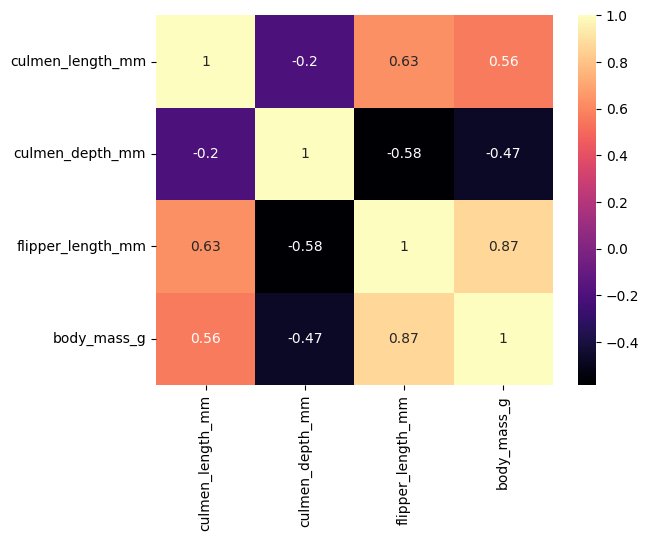

In [16]:
sns.heatmap(df.corr(numeric_only=True),cmap='magma',annot=True)

In [17]:
#Standardize the data
scaler=StandardScaler()
numerical_features_scaled=scaler.fit_transform(numerical_features)
numerical_features_scaled

array([[-0.89003271,  0.76598091, -1.45408172, -0.54347459],
       [-0.81509001,  0.10885993, -1.08162944, -0.47722759],
       [-0.6652046 ,  0.41214654, -0.41121534, -1.20594458],
       ...,
       [ 1.22709868, -0.75045213,  1.60002697,  2.10640535],
       [ 0.25284353, -1.20538204,  0.85512241,  1.37768836],
       [ 1.1334203 , -0.54826106,  0.92961287,  1.64267636]])

In [18]:
cov_matr_num=np.cov(numerical_features_scaled.T)
cov_matr_num

array([[ 1.00314465, -0.20413104,  0.63108862,  0.56578473],
       [-0.20413104,  1.00314465, -0.58570363, -0.47335857],
       [ 0.63108862, -0.58570363,  1.00314465,  0.86959284],
       [ 0.56578473, -0.47335857,  0.86959284,  1.00314465]])

array([2.7186791 , 0.80282933, 0.37894761, 0.11212258])

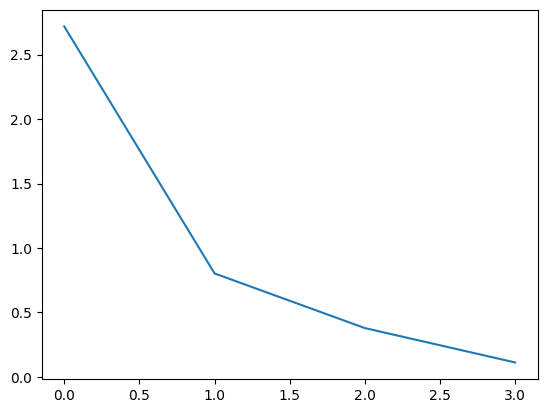

In [19]:
eigenvals,eigenvecs=np.linalg.eig(cov_matr_num)
plt.plot(eigenvals)
eigenvals

In [20]:
transformer=PCA(2)
numerical_features_trans=transformer.fit_transform(numerical_features_scaled)
transformer.components_

array([[ 0.44334389, -0.40306756,  0.58029551,  0.55157943],
       [ 0.63354954,  0.77125282, -0.00647143,  0.06117345]])

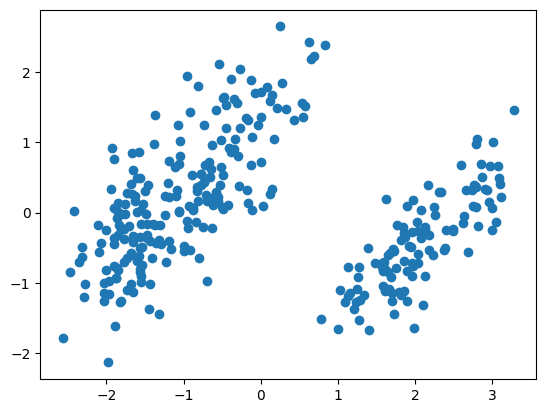

In [21]:
plt.scatter(*numerical_features_trans.T)

In [23]:
sum_eigenvals=sum(eigenvals)
expl_var_ratio=[val/sum_eigenvals for val in eigenvals]
expl_var_ratio

[np.float64(0.6775391479239209),
 np.float64(0.20007815486625086),
 np.float64(0.09443992145272181),
 np.float64(0.027942775757106315)]

In [26]:
#better practise in ML is using numpy:
expl_var_ratio=eigenvals/eigenvals.sum()
expl_var_ratio

array([0.67753915, 0.20007815, 0.09443992, 0.02794278])